In [1]:
!pip install shap

In [3]:
import ee
import math
import geemap
import pprint
import datetime
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict
from statistics import mean, pstdev
import matplotlib.dates as mdates
import ee
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import shap
import re
from sklearn.preprocessing import StandardScaler

ee.Authenticate
ee.Initialize(project='toribiodiego-ece471')

# Homework 2
- ECE471: Fundamentals of Remote Sensing and Earth Observation
- Spring 2025
- Instructor: Krishna Karra
- Contact: krishna.karra@cooper.edu (Teams chat is quickest)
- Assigned: Wednesday, February 26, 2025
- Due: Tuesday, March 18, 2025 (by midnight EST)

## Problem Motivation

The United States Department of Agriculture (USDA), in conjunction with the United States Geological Survey (USGS), produces the Cropland Data Layer (CDL), an annual landcover map of crop types across the Continental United States at 30-meter resolution. This map, which incorporates Landsat and Sentinel imagery from across the year, represents some of the highest quality, rigorously validated land cover classification that can be found anywhere.

A year's annual map is usually released a few months into the next year (e.g. the 2020 CDL is released towards the end of the first quarter of 2021). As a geospatial consultant, your task is to investigate whether certain crop types could be predicted *in-season* (e.g. without using a full year's worth of imagery).

The CDL is used within government and industry for crop health monitoring, crop area estimation, agricultural policy development, environmental monitoring, yield forecasting and more. In-season prediction of crop types would be vastly useful for all of these applications.

For this pilot study, the focus will be on Iowa and Illinois.

## Problem Overview

The overall workflow will be:

1. Analyze cropland data to identify the 5 most prevalent crops grown in Iowa and Illinois.
2. Explore and visualize the seasonal patterns of those 5 crops using vegetation index time series analysis.
3. Develop a crop identification model that takes satellite imagery as input and predicts crop type at the pixel level.
4. Assess model performance using validation data and metrics.
5. Apply the model to full counties to produce crop type maps and compare against ground truth data.

The core data sources will be:

1. Cropland Data Layer (CDL) for crop type ground truth labels
2. Landsat satellite imagery for model inputs
3. Google Earth Engine (GEE) platform for analysis and modeling

This assignment will give you real, concrete experience with:

- Working with large-scale geospatial data
- Time series analysis of vegetation indices
- Developing and validating a remote sensing model
- Creating meaningful data visualizations and maps

Your modeling approach and additional data sources are flexible. The key deliverables are: ranked crop list, crop seasonal analysis, trained crop identification model, model evaluations, and final county-level crop maps.

## Task 1: Identify Most Prevalent Crops

###*Goal: Plan to have made significant progress on Task 1 (or completed it) by March 5.*

The goal of this task is to create a ranked list of the most commonly grown crops across Iowa and Illinois based on acreage data from the 2019 Cropland Data Layer (CDL).

Specifically, you should:

1. Load the 2019 CDL raster data for the 2 states from Google Earth Engine.
2. Write a script to calculate the total acreage of each unique crop type in the CDL legend across the 2 states.
3. Rank the crops based on total acreage from most to least.
4. Output the list as a CSV file with two columns: Crop Name and Total Acres. Include the top 20 crops. Include the top 20 crops.
5. From this list, select the top 5 most prevalent crops. These will be the focus for the rest of the analysis.

Things to keep in mind:

1. Analysis must be done programmatically using GEE.
2. Output must be a clean CSV file with the columns specified.
3. Make sure to handle any data filtering or preprocessing steps like reprojections.
4. Document your methodology and thought process

### 1.0 - Helper Functions

In [4]:
def compute_crop_acreage_table(
    region,
    crop_legend,
    area_name=None,
    verbose=False,
    top5=False,
    global_stats=False,
    produce_top20_csv=False,
):
    """
    Compute crop acreage statistics for the given region using the 2019 USDA CDL.
    Returns a formatted table (string) with Rank, Crop Code, Crop Name, Total Acres, and % of total.
    Optionally prints global stats and exports a CSV for the top 20 crops.
    """
    # Load the 2019 CDL image.
    cdl_2019 = ee.Image("USDA/NASS/CDL/2019")

    # Calculate total area in the region in acres.
    area_image = ee.Image.pixelArea().multiply(0.000247105)
    total_area_stats = area_image.reduceRegion(
        reducer=ee.Reducer.sum(), geometry=region, scale=30, maxPixels=1e13
    )
    total_area_in_acres = total_area_stats.getInfo().get("area", 0)

    # Combine the area image with the CDL cropland band.
    combined_image = area_image.addBands(cdl_2019.select("cropland"))

    # Sum area by crop code.
    reducer = ee.Reducer.sum().group(groupField=1, groupName="crop_code")
    stats = combined_image.reduceRegion(
        reducer=reducer, geometry=region, scale=30, maxPixels=1e13
    )
    groups = stats.get("groups")
    if groups is None:
        return "No crop data found for this region."
    groups = groups.getInfo()

    # Prepare per-crop data.
    table_data = []
    total_crop_acres = sum(entry["sum"] for entry in groups)
    for entry in groups:
        crop_code = entry["crop_code"]
        acreage = entry["sum"]
        crop_name = crop_legend.get(crop_code, "Unknown")
        pct_crops = (acreage / total_crop_acres) * 100 if total_crop_acres else 0
        table_data.append(
            {
                "Code": crop_code,
                "Name": crop_name,
                "Total": round(acreage),
                "Area (%)": round(pct_crops),
            }
        )

    # Sort by Total Acres descending and add rank.
    table_data_sorted = sorted(table_data, key=lambda x: x["Total"], reverse=True)
    for idx, row in enumerate(table_data_sorted, start=1):
        row["Rank"] = idx

    final_data = []
    for row in table_data_sorted:
        final_data.append(
            {
                "Rank": row["Rank"],
                "Code": row["Code"],
                "Name": row["Name"],
                "Total": row["Total"],
                "%": row["Area (%)"],
            }
        )

    # Format data for display.
    display_data = []
    for row in final_data:
        new_row = row.copy()
        new_row["Total"] = format(row["Total"], ",")
        for word in ["Intensity", "Space"]:
            new_row["Name"] = new_row["Name"].replace(word, "")
        new_row["Name"] = new_row["Name"].strip()
        display_data.append(new_row)

    data_to_print = display_data if verbose or not top5 else display_data[:5]
    table_str = tabulate(data_to_print, headers="keys", tablefmt="grid")

    # Print global stats if requested.
    if global_stats:
        unique_crops = len(final_data)
        global_stats_data = [
            {
                "# Unique Crops": unique_crops,
                "Total Area": format(round(total_area_in_acres), ","),
            }
        ]
        global_stats_table = tabulate(
            global_stats_data, headers="keys", tablefmt="grid"
        )
        table_str = table_str + "\n" + global_stats_table

    # Export CSV for top 20 crops if requested.
    if produce_top20_csv:
        csv_filename = (
            f"{area_name}_top20_crops.csv" if area_name else "top20_crops.csv"
        )
        df = pd.DataFrame(final_data)
        df_top20 = df.sort_values(by="Total", ascending=False).head(20)
        df_top20 = df_top20[["Name", "Total"]]
        df_top20.to_csv(csv_filename, index=False)
        print(f"[INFO] CSV file saved as: {csv_filename}")

    return table_str


def get_state_geometry(state_abbr_list):
    """
    Return a combined ee.Geometry for the states provided.
    """
    states = ee.FeatureCollection("TIGER/2018/States")
    fc_filtered = states.filter(ee.Filter.inList("STUSPS", state_abbr_list))
    return fc_filtered.geometry()


def get_county_geometry(state_fips, county_name):
    """
    Retrieve the ee.Geometry for a county given its state FIPS and county name.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    county_fc = counties.filter(ee.Filter.eq("STATEFP", state_fips)).filter(
        ee.Filter.eq("NAME", county_name)
    )
    return county_fc.first().geometry()


def get_county_spread(state_fips, verbose=True):
    """
    Return (smallest, median, largest) counties for a given state (by FIPS code) based on acreage.
    Prints a summary table if verbose=True.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties").filter(
        ee.Filter.eq("STATEFP", state_fips)
    )
    counties_info = counties.getInfo()["features"]
    sqm_to_acres = 0.000247105
    county_land_area = []
    for f in counties_info:
        props = f["properties"]
        name = props["NAME"]
        acres = props["ALAND"] * sqm_to_acres
        county_land_area.append((name, round(acres)))
    county_land_area.sort(key=lambda x: x[1])
    smallest = county_land_area[0]
    largest = county_land_area[-1]
    mid_idx = len(county_land_area) // 2
    median = county_land_area[mid_idx]

    if verbose:
        spread_data = [
            {
                "Type": "Smallest",
                "County Name": smallest[0],
                "Acreage": format(smallest[1], ","),
            },
            {
                "Type": "Median",
                "County Name": median[0],
                "Acreage": format(median[1], ","),
            },
            {
                "Type": "Largest",
                "County Name": largest[0],
                "Acreage": format(largest[1], ","),
            },
        ]
        print(tabulate(spread_data, headers="keys", tablefmt="grid"))

    return smallest, median, largest

### 1.1 - Rectangular Region (Central Iowa)

In [ ]:
# define a small rectangular geometry (e.g., in Central Iowa)
test_region = ee.Geometry.Rectangle([-93.75, 41.6, -93.6, 41.7])

# load the 2019 CDL image and build a crop legend
cdl_2019 = ee.Image("USDA/NASS/CDL/2019")

crop_class_names = cdl_2019.get("cropland_class_names").getInfo()
crop_class_values = cdl_2019.get("cropland_class_values").getInfo()

# if properties are strings, convert them to lists
if isinstance(crop_class_names, str):
    crop_class_names = crop_class_names.split(",")

if isinstance(crop_class_values, str):
    crop_class_values = [int(val) for val in crop_class_values.split(",")]
crop_legend = dict(zip(crop_class_values, crop_class_names))

# compute the crop acreage table for the test region
table_str = compute_crop_acreage_table(
    region=test_region,
    crop_legend=crop_legend,
    area_name="test_rectangle",
    verbose=False,
    top5=True,  # print top 5
    global_stats=True,  # print global statistics
    produce_top20_csv=False,
)


print(table_str)
print(
    "\n\033[1mTable 1\033[0m. Crop Acreage Table (top 5) with global statistics for the small test region (Central Iowa)."
)


+--------+--------+----------------+---------+-----+
|   Rank |   Code | Name           | Total   |   % |
+========+========+================+=========+=====+
|      1 |    122 | Developed/Low  | 11,224  |  33 |
+--------+--------+----------------+---------+-----+
|      2 |    121 | Developed/Open | 6,810   |  20 |
+--------+--------+----------------+---------+-----+
|      3 |    123 | Developed/Med  | 3,931   |  11 |
+--------+--------+----------------+---------+-----+
|      4 |    190 | Woody Wetlands | 2,124   |   6 |
+--------+--------+----------------+---------+-----+
|      5 |    176 | Grass/Pasture  | 2,032   |   6 |
+--------+--------+----------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               24 | 34,299       |
+------------------+--------------+

Table 1. Crop Acreage Table (top 5) with global statistics for the small test region (Central Iowa).


### 1.2 - Iowa County Spread

In [ ]:
# get the smallest, median, and largest counties by land area.
smallest_county, median_county, largest_county = get_county_spread(state_fips="19")

# retrieve the geometries for each.
smallest_geom = get_county_geometry("19", smallest_county[0])
median_geom = get_county_geometry("19", median_county[0])
largest_geom = get_county_geometry("19", largest_county[0])

#### 1.2.1 - Smallest County

In [ ]:
table_small = compute_crop_acreage_table(
    region=smallest_geom,
    crop_legend=crop_legend,
    area_name="Iowa_smallest_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False,
)
print(table_small)
print(
    "\n\033[1mTable 2\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's smallest county (Dickinson)."
)

+--------+--------+---------------------+---------+-----+
|   Rank |   Code | Name                | Total   |   % |
+========+========+=====================+=========+=====+
|      1 |      1 | Corn                | 94,176  |  36 |
+--------+--------+---------------------+---------+-----+
|      2 |      5 | Soybeans            | 76,273  |  30 |
+--------+--------+---------------------+---------+-----+
|      3 |    176 | Grass/Pasture       | 25,505  |  10 |
+--------+--------+---------------------+---------+-----+
|      4 |    195 | Herbaceous Wetlands | 17,314  |   7 |
+--------+--------+---------------------+---------+-----+
|      5 |    111 | Open Water          | 15,564  |   6 |
+--------+--------+---------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               30 | 258,535      |
+------------------+--------------+

Table 2. Crop Acreage Table (top 5) with global statistics for Io

#### 1.2.2 - Median County

In [ ]:
table_median = compute_crop_acreage_table(
    region=median_geom,
    crop_legend=crop_legend,
    area_name="Iowa_median_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False,
)
print(table_median)
print(
    "\n\033[1mTable 3\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's median county (Greene)."
)

+--------+--------+------------------+---------+-----+
|   Rank |   Code | Name             | Total   |   % |
+========+========+==================+=========+=====+
|      1 |      1 | Corn             | 177,537 |  49 |
+--------+--------+------------------+---------+-----+
|      2 |      5 | Soybeans         | 120,595 |  33 |
+--------+--------+------------------+---------+-----+
|      3 |    176 | Grass/Pasture    | 23,398  |   6 |
+--------+--------+------------------+---------+-----+
|      4 |    121 | Developed/Open   | 13,267  |   4 |
+--------+--------+------------------+---------+-----+
|      5 |    141 | Deciduous Forest | 11,484  |   3 |
+--------+--------+------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               28 | 365,611      |
+------------------+--------------+

Table 3. Crop Acreage Table (top 5) with global statistics for Iowa's median county (Greene).


#### 1.2.3 - Largest County

In [ ]:
table_large = compute_crop_acreage_table(
    region=largest_geom,
    crop_legend=crop_legend,
    area_name="Iowa_largest_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False,
)
print(table_large)
print(
    "\n\033[1mTable 4\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's largest county (Kossuth)."
)

+--------+--------+---------------------+---------+-----+
|   Rank |   Code | Name                | Total   |   % |
+========+========+=====================+=========+=====+
|      1 |      1 | Corn                | 317,292 |  51 |
+--------+--------+---------------------+---------+-----+
|      2 |      5 | Soybeans            | 205,863 |  33 |
+--------+--------+---------------------+---------+-----+
|      3 |    176 | Grass/Pasture       | 32,508  |   5 |
+--------+--------+---------------------+---------+-----+
|      4 |    121 | Developed/Open      | 21,438  |   3 |
+--------+--------+---------------------+---------+-----+
|      5 |    195 | Herbaceous Wetlands | 14,077  |   2 |
+--------+--------+---------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               31 | 623,565      |
+------------------+--------------+

Table 4. Crop Acreage Table (top 5) with global statistics for Io

### 1.3 - Iowa and Illinois

In [ ]:
# create a combined geometry for Iowa + Illinois
ia_il_geometry = get_state_geometry(["IA", "IL"])

# demonstrates producing a CSV with top 20 crops
table_ia_il = compute_crop_acreage_table(
    region=ia_il_geometry,
    crop_legend=crop_legend,
    area_name="Iowa_Illinois",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=True,
)
print(table_ia_il)
print(
    "\n\033[1mTable 5\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa + Illinois."
)


[INFO] CSV file saved as: Iowa_Illinois_top20_crops.csv
+--------+--------+------------------+------------+-----+
|   Rank |   Code | Name             | Total      |   % |
+========+========+==================+============+=====+
|      1 |      1 | Corn             | 24,044,494 |  33 |
+--------+--------+------------------+------------+-----+
|      2 |      5 | Soybeans         | 18,860,571 |  26 |
+--------+--------+------------------+------------+-----+
|      3 |    141 | Deciduous Forest | 7,935,511  |  11 |
+--------+--------+------------------+------------+-----+
|      4 |    176 | Grass/Pasture    | 7,378,873  |  10 |
+--------+--------+------------------+------------+-----+
|      5 |    121 | Developed/Open   | 2,690,743  |   4 |
+--------+--------+------------------+------------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               66 | 73,078,611   |
+------------------+--------------+

Table 6. 

## Task 2: Crop Seasonal Analysis

###*Goal: Plan to have made significant progress by March 5*

Goal: Analyze the seasonal patterns of the top 5 crops using vegetation index time series.

Overview:

1. Sample pixels growing for each crop across the two states
2. Compute NDVI time series for each crop sample
3. Generate visualizations of the NDVI curves
4. Perform additional analysis on crop emergence, harvest dates, etc (optional)

This will reveal unique temporal signatures of the crops and inform model development.

### 2.0 - Helper Functions

In [29]:
# define label property and crop dictionary
label_property = "crop_code"
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space",
}


def create_grid(region, cell_size):
    """
    Create a grid of square cells covering the given region.
    """
    bounds = region.bounds()
    coords = ee.List(ee.List(bounds.coordinates().get(0)))
    lons = coords.map(lambda pt: ee.Number(ee.List(pt).get(0)))
    lats = coords.map(lambda pt: ee.Number(ee.List(pt).get(1)))
    min_lon = ee.Number(lons.reduce(ee.Reducer.min()))
    max_lon = ee.Number(lons.reduce(ee.Reducer.max()))
    min_lat = ee.Number(lats.reduce(ee.Reducer.min()))
    max_lat = ee.Number(lats.reduce(ee.Reducer.max()))
    cell_deg = ee.Number(cell_size).divide(111000)  # convert meters to degrees
    lon_list = ee.List.sequence(min_lon, max_lon, cell_deg)
    lat_list = ee.List.sequence(min_lat, max_lat, cell_deg)

    def make_cell(lon):
        def make_cell_inner(lat):
            cell = ee.Geometry.Rectangle(
                [lon, lat, ee.Number(lon).add(cell_deg), ee.Number(lat).add(cell_deg)]
            )
            return ee.Feature(cell)

        return lat_list.map(make_cell_inner)

    grid = lon_list.map(make_cell)
    return ee.FeatureCollection(ee.List(grid).flatten())


def sample_crop_locations(cdl_image, crop_code, crop_name, region_geom, num_points):
    """
    Sample crop locations using stratified sampling from the CDL 'cropland' band.
    """
    samples = cdl_image.stratifiedSample(
        numPoints=0,  # Ignored when using classValues/classPoints.
        classBand="cropland",
        region=region_geom,
        scale=30,
        classValues=[crop_code],
        classPoints=[num_points],
        seed=42,
        geometries=True,
        dropNulls=True,
    )
    return samples


def mask_landsat_clouds_sr(image):
    """
    Apply a cloud/shadow/snow/water mask to a Landsat image.
    """
    qa_pixel = image.select("QA_PIXEL")
    mask = (
        qa_pixel.bitwiseAnd(1 << 3)
        .eq(0)
        .And(qa_pixel.bitwiseAnd(1 << 4).eq(0))
        .And(qa_pixel.bitwiseAnd(1 << 5).eq(0))
        .And(qa_pixel.bitwiseAnd(1 << 7).eq(0))
    )
    return image.updateMask(mask)


def add_ndvi(image):
    """
    Compute NDVI and add it as a band to the image.
    """
    ndvi = image.expression(
        "(NIR - RED) / (NIR + RED)",
        {
            "NIR": image.select("SR_B5").multiply(0.0000275).add(-0.2),
            "RED": image.select("SR_B4").multiply(0.0000275).add(-0.2),
        },
    ).rename("NDVI")
    return image.addBands(ndvi)


def get_landsat_ndvi_collection(
    start_date="2019-01-01", end_date="2019-12-31", region=None
):
    """
    Build an NDVI collection from Landsat 8/9 using specified date range and region.
    """
    l8_sr = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(
        start_date, end_date
    )
    if region:
        l8_sr = l8_sr.filterBounds(region)
    l8_sr = l8_sr.map(mask_landsat_clouds_sr).map(add_ndvi)
    return l8_sr.select(["NDVI", "QA_PIXEL"])


def extract_ndvi_time_series(ndvi_collection, sample_points):
    """
    Extract NDVI time series from the image collection for given sample points.
    """

    def per_image(image):
        date_str = image.date().format("YYYY-MM-dd")
        sampled = (
            image.select("NDVI")
            .sampleRegions(collection=sample_points, scale=30, geometries=True)
            .map(lambda f: f.set("date", date_str))
        )
        return sampled

    return ndvi_collection.map(per_image).flatten()


def aggregate_ndvi_by_date(timeseries_fc):
    """
    Aggregate daily NDVI values across sample points.
    """
    fc_list = timeseries_fc.toList(timeseries_fc.size()).getInfo()
    data_by_date = defaultdict(list)
    for feat in fc_list:
        props = feat["properties"]
        date_str = props.get("date")
        ndvi_val = props.get("NDVI")
        if date_str is not None and ndvi_val is not None:
            data_by_date[date_str].append(ndvi_val)
    results = []
    for date_str, ndvi_vals in data_by_date.items():
        if ndvi_vals:
            results.append(
                {
                    "date": date_str,
                    "mean_ndvi": mean(ndvi_vals),
                    "std_dev": pstdev(ndvi_vals),
                    "count": len(ndvi_vals),
                }
            )
    results.sort(key=lambda x: x["date"])
    return results


def plot_ndvi_time_series(ndvi_stats, title="NDVI Time Series"):
    """
    Plot the NDVI time series with mean and variability.
    """
    if not ndvi_stats:
        print("No NDVI data to plot.")
        return
    dates = [datetime.strptime(e["date"], "%Y-%m-%d") for e in ndvi_stats]
    means = [e["mean_ndvi"] for e in ndvi_stats]
    stdevs = [e["std_dev"] for e in ndvi_stats]
    plus_1sigma = [m + s for m, s in zip(means, stdevs)]
    minus_1sigma = [m - s for m, s in zip(means, stdevs)]
    plus_2sigma = [m + 2 * s for m, s in zip(means, stdevs)]
    minus_2sigma = [m - 2 * s for m, s in zip(means, stdevs)]
    plt.figure(figsize=(8, 5))
    plt.fill_between(dates, minus_2sigma, plus_2sigma, alpha=0.1, label="±2σ")
    plt.fill_between(dates, minus_1sigma, plus_1sigma, alpha=0.2, label="±1σ")
    plt.plot(dates, means, label="Mean NDVI")
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))
    plt.show()


def get_county_geometry(state_fips, county_name):
    """
    Retrieve the geometry of a county given its state FIPS code and county name.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    county_fc = counties.filter(ee.Filter.eq("STATEFP", state_fips)).filter(
        ee.Filter.eq("NAME", county_name)
    )
    return county_fc.first().geometry()


def get_county_spread(state_fips, verbose=True):
    """
    Return (smallest, median, largest) counties by acreage for a given state.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties").filter(
        ee.Filter.eq("STATEFP", state_fips)
    )
    counties_info = counties.getInfo()["features"]
    sqm_to_acres = 0.000247105
    county_land_area = [
        (f["properties"]["NAME"], round(f["properties"]["ALAND"] * sqm_to_acres))
        for f in counties_info
    ]
    county_land_area.sort(key=lambda x: x[1])
    smallest = county_land_area[0]
    largest = county_land_area[-1]
    median = county_land_area[len(county_land_area) // 2]
    if verbose:
        table = [
            ["Smallest", smallest[0]],
            ["Median", median[0]],
            ["Largest", largest[0]],
        ]
        print(tabulate(table, headers=["Type", "County"], tablefmt="grid"))
    return smallest, median, largest


def process_top5_crops(input_geom, top_5_crops, year="2019", region_name="Region", verbose=True, fig_index=1):
    """
    Process the top 5 crops for the given geometry and plot their NDVI time series.
    Prints a dynamic figure description for each crop, including the region name.
    """
    cdl_image = ee.Image("USDA/NASS/CDL/2019").select("cropland").clip(input_geom)
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    ndvi_collection = get_landsat_ndvi_collection(start_date, end_date, input_geom)

    for crop_code, crop_name in top_5_crops.items():
        sample_fc = sample_crop_locations(
            cdl_image=cdl_image,
            crop_code=crop_code,
            crop_name=crop_name,
            region_geom=input_geom,
            num_points=250,
        )
        ndvi_ts = extract_ndvi_time_series(ndvi_collection, sample_fc)
        agg_data = aggregate_ndvi_by_date(ndvi_ts)

        if verbose and agg_data:
            table_rows = [
                {
                    "Date": row["date"],
                    "Mean NDVI": f"{row['mean_ndvi']:.4f}",
                    "Std Dev": f"{row['std_dev']:.4f}",
                    "Count": row["count"],
                }
                for row in agg_data
            ]
            print(tabulate(table_rows, headers="keys", tablefmt="grid"))

        title = f"{crop_name} ({year})"
        plot_ndvi_time_series(agg_data, title=title)
        print(f"\n\033[1mFigure {fig_index}\033[0m. NDVI Time Series for {crop_name} in {region_name} ({year})")
        fig_index += 1

def add_monthly_ndvi(feature):
    year = 2019

    def month_fn(m, feat):
        start = ee.Date.fromYMD(year, ee.Number(m), 1)
        end = start.advance(1, "month")
        monthly_mean = (
            ndvi_collection.filterDate(start, end)
            .mean()
            .select("NDVI")
            .reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=ee.Feature(feat).geometry(),
                scale=30,
                bestEffort=True,
            )
            .get("NDVI")
        )
        return ee.Feature(feat).set(f"NDVI_{int(m)}", monthly_mean)

    months = ee.List.sequence(1, 12)
    return ee.Feature(months.iterate(month_fn, feature))

def export_ndvi_timeseries_asset(fc, crop_name, region_name, year="2019"):
    """
    Export the NDVI time series as an asset.
    """
    safe_crop_name = crop_name.replace(" ", "_").replace("/", "_")
    asset_id = f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{region_name}_{safe_crop_name}_{year}"
    description = f"Asset_NDVI_TS_{region_name}_{safe_crop_name}_{year}"
    task = ee.batch.Export.table.toAsset(
        collection=fc, description=description, assetId=asset_id, fileFormat="CSV"
    )
    task.start()


def load_ee_asset_to_list(asset_id):
    """
    Load an Earth Engine asset into a Python list.
    """
    fc = ee.FeatureCollection(asset_id)
    fc_info = fc.getInfo()
    features = fc_info.get("features", [])
    return [feat["properties"] for feat in features]


def aggregate_ndvi_monthly(ndvi_data):
    """
    Aggregate daily NDVI data to monthly averages.
    """
    data_by_month = defaultdict(list)
    for entry in ndvi_data:
        date_str = entry.get("date")
        ndvi_val = entry.get("mean_ndvi")
        if date_str and ndvi_val is not None:
            dt = datetime.strptime(date_str, "%Y-%m-%d")
            ym = (dt.year, dt.month)
            data_by_month[ym].append(ndvi_val)
    monthly_results = []
    for (yr, mo), ndvi_vals in data_by_month.items():
        if ndvi_vals:
            monthly_results.append(
                {
                    "date": datetime(yr, mo, 1).strftime("%Y-%m-%d"),
                    "mean_ndvi": mean(ndvi_vals),
                    "std_dev": pstdev(ndvi_vals) if len(ndvi_vals) > 1 else 0,
                    "count": len(ndvi_vals),
                }
            )
    monthly_results.sort(key=lambda x: x["date"])
    return monthly_results


def plot_ndvi_time_series_from_list(ndvi_stats, title="NDVI Time Series"):
    """
    Plot a monthly NDVI time series from a Python list of statistics.
    """
    if not ndvi_stats:
        print("No NDVI data to plot.")
        return
    dates = [datetime.strptime(entry["date"], "%Y-%m-%d") for entry in ndvi_stats]
    means = [entry["mean_ndvi"] for entry in ndvi_stats]
    stdevs = [entry["std_dev"] for entry in ndvi_stats]
    plus_1sigma = [m + s for m, s in zip(means, stdevs)]
    minus_1sigma = [m - s for m, s in zip(means, stdevs)]
    plus_2sigma = [m + 2 * s for m, s in zip(means, stdevs)]
    minus_2sigma = [m - 2 * s for m, s in zip(means, stdevs)]
    plt.figure(figsize=(8, 5))
    plt.fill_between(dates, minus_2sigma, plus_2sigma, alpha=0.1, label="±2σ")
    plt.fill_between(dates, minus_1sigma, plus_1sigma, alpha=0.2, label="±1σ")
    plt.plot(dates, means, marker="o", label="Mean NDVI")
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))
    plt.show()

### Task 2.1: Sample Crop Pixel Locations

- Write a script to randomly sample at least 250 pixel locations for each of the 5 crops.
- Spread the sampling across the 2 states to capture geographical diversity.
- Output the sampled points as a FeatureCollection in GEE.
- Visualize the points to ensure they look as expected.
- Document your sampling methodology (e.g. spatial filters, randomization, etc.)
- The sampling script should be modular to allow increasing the sampling size.

#### 2.1.2 - Smallest County in Iowa

In [27]:
# specify state and county
state_fips = "19"
county_name = "Dickinson"

# get county geometry
county_geom = get_county_geometry(state_fips, county_name)

# clip the CDL image (2019) to the county geometry
cdl_image = ee.Image("USDA/NASS/CDL/2019").select("cropland").clip(county_geom)

# define a color mapping for each crop
crop_colors = {
    "Corn": "red",
    "Soybeans": "blue",
    "Deciduous Forest": "green",
    "Grass/Pasture": "yellow",
    "Developed/Open Space": "magenta",
}

# create an interactive map for the county
center = county_geom.centroid().coordinates().getInfo()[::-1]  # [lat, lon]
m_county = geemap.Map(center=center, zoom=11)
m_county.addLayer(
    county_geom, {"color": "grey", "fillColor": "00000000"}, f"{county_name} Geometry"
)

# sample points for the top 5 crops and add each as a layer with its designated color
for crop_code, crop_name in top_5_crops.items():
    samples = sample_crop_locations(
        cdl_image, crop_code, crop_name, county_geom, num_points=250
    )
    color = crop_colors.get(crop_name, "red")  # default to red if not found
    m_county.addLayer(samples, {"color": color}, f"Samples: {crop_name}")

m_county.addLayerControl()
m_county


Map(center=[43.37798452295224, -95.15082718314032], controls=(WidgetControl(options=['position', 'transparent_…

#### 2.1.3 - Iowa and Illinois

### Task 2.2: Calculate NDVI Time Series

- For each crop, use the sampled points to extract NDVI values over a full year.
- Use all available Landsat surface reflectance imagery from 2019.
- Handle clouds/shadows by filtering out low quality NDVI values.
- Calculate the mean, 1-sigma, and 2-sigma NDVI curves for each crop across the time series.
- Plot the NDVI curves with date on x-axis and NDVI on y-axis.
- Include the crop name, number of sample points, and time range in the plot.
- Document your approach for filtering, aggregating, and plotting the time series data.

Key requirements:

- Use GEE reducers to extract NDVI values per pixel.
- Make sure to mask clouds and filter low quality NDVI.
- Plot mean, 1-sigma, and 2-sigma to show variability across many samples
- Output clean, labeled, and informative plots.

#### 2.2.1 - Helper Functions

#### 2.2.2 - Largest County in Iowa

In this section, we process the NDVI time series for the largest county in Iowa as an initial test. By focusing on a single, large county, we can verify that our sampling, NDVI extraction, and aggregation functions work as expected on a smaller scale. This pilot analysis helps us identify any potential issues with our approach—such as performance bottlenecks—before scaling up to larger areas.

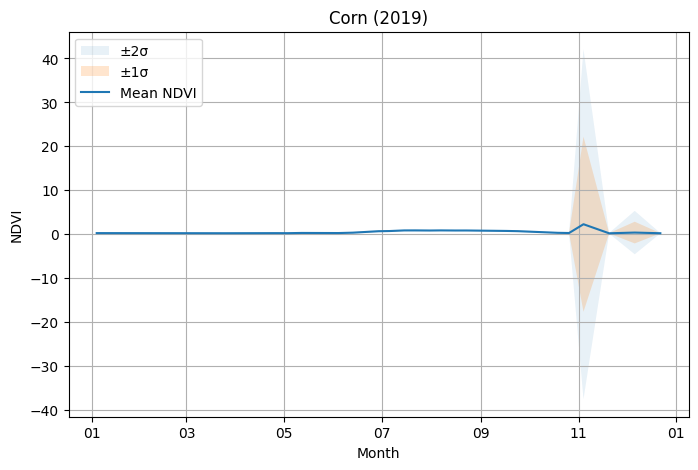


Figure 1. NDVI Time Series for Corn in Kossuth (2019)


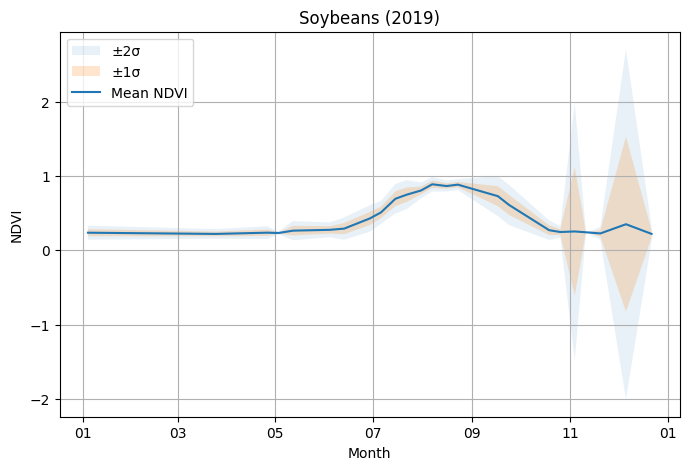


Figure 2. NDVI Time Series for Soybeans in Kossuth (2019)


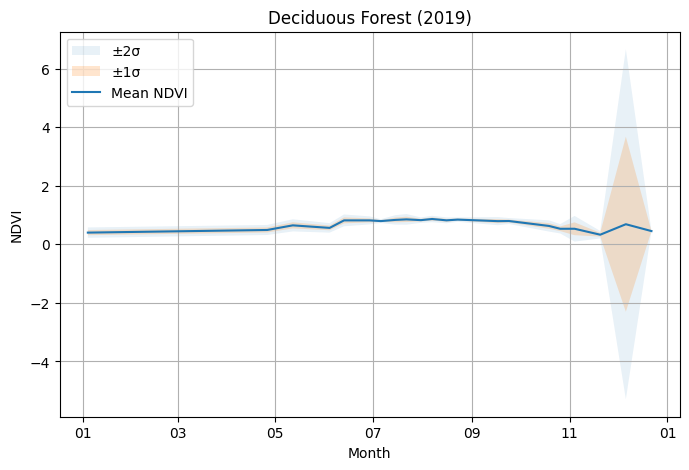


Figure 3. NDVI Time Series for Deciduous Forest in Kossuth (2019)


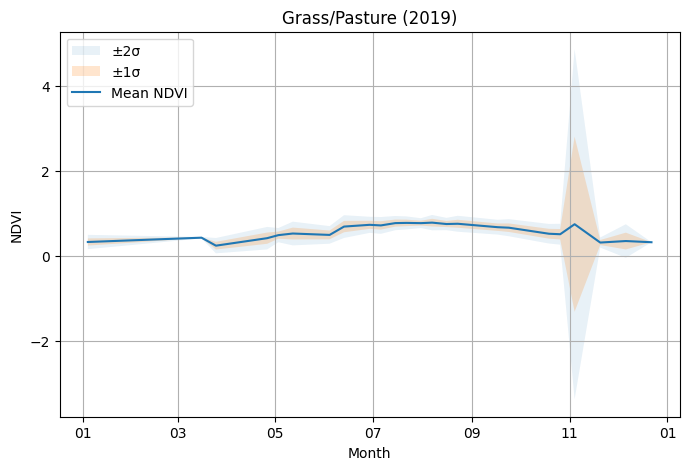


Figure 4. NDVI Time Series for Grass/Pasture in Kossuth (2019)


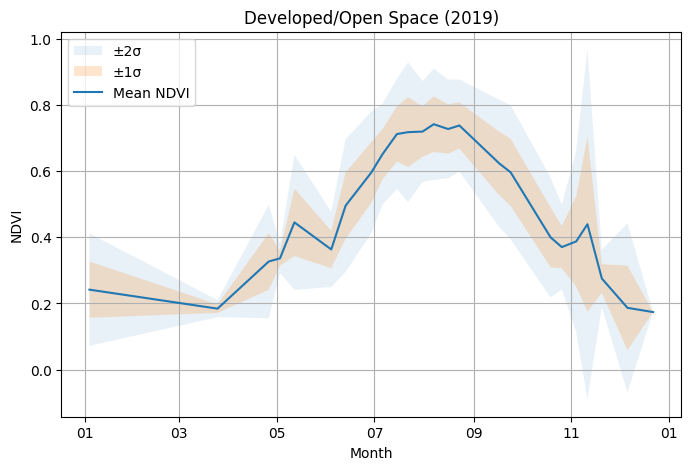


Figure 5. NDVI Time Series for Developed/Open Space in Kossuth (2019)


In [28]:
state_fips = "19"
smallest, median, largest = get_county_spread(state_fips, verbose=False)
largest_county_name = largest[0]

# get the county geometry for the largest county
county_geom = get_county_geometry(state_fips, largest_county_name)

process_top5_crops(
    county_geom,
    top_5_crops,
    year="2019",
    region_name=largest_county_name,
    verbose=False,
    fig_index=1,
)


#### 2.2.3 - Iowa and Illinois

**Scaling Up:** Exporting NDVI Time Series as Assets for Larger Regions

For state-wide analyses, such as in Iowa and Illinois, the increased data volume (with each crop requiring about 250 samples) can lead to timeouts when processed directly. To address this, we export the aggregated NDVI time series as Earth Engine assets. This approach offloads the heavy computations to Earth Engine’s infrastructure, allowing us to load the pre-processed assets later for aggregation and plotting. Scaling up from a single county to entire states also helped us understand and manage the computational challenges that arise with larger regions.


In [14]:
# get geometries for Iowa and Illinois
iowa_geom = get_state_geometry(["IA"])
illinois_geom = get_state_geometry(["IL"])

# load the 2019 CDL cropland band
cdl_2019 = ee.Image("USDA/NASS/CDL/2019").select("cropland")

# sample 250 points for each crop in Iowa and Illinois
for crop_code, crop_name in top_5_crops.items():
    iowa_samples = sample_crop_locations(
        cdl_image=cdl_2019.clip(iowa_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=iowa_geom,
        num_points=250,
    ).map(lambda f: f.set("state", "Iowa"))

    illinois_samples = sample_crop_locations(
        cdl_image=cdl_2019.clip(illinois_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=illinois_geom,
        num_points=250,
    ).map(lambda f: f.set("state", "Illinois"))

    combined_samples = iowa_samples.merge(illinois_samples).map(
        lambda f: f.set("crop_code", crop_code, "crop_name", crop_name)
    )

    # export the combined samples as an asset
    export_sampling_asset(
        fc=combined_samples, crop_name=crop_name, year="2019", region_name="IA_IL"
    )

In [18]:
# define the region covering Iowa and Illinois
ia_il_geom = (
    ee.FeatureCollection("TIGER/2018/States")
    .filter(ee.Filter.inList("STUSPS", ["IA", "IL"]))
    .geometry()
)

start_date = "2019-01-01"
end_date = "2019-12-31"

# build an NDVI collection for 2019 over the combined region
ndvi_collection = get_landsat_ndvi_collection(start_date, end_date, ia_il_geom)

# define paths to sampling assets (~500 points per crop: 250 per state)
sampling_assets = {
    "Corn": "projects/toribiodiego-ece471/assets/sampling/SAMPLING_IA_IL_Corn_2019",
    "Soybeans": "projects/toribiodiego-ece471/assets/sampling/SAMPLING_IA_IL_Soybeans_2019",
    "Deciduous_Forest": "projects/toribiodiego-ece471/assets/sampling/SAMPLING_IA_IL_Deciduous_Forest_2019",
    "Grass_Pasture": "projects/toribiodiego-ece471/assets/sampling/SAMPLING_IA_IL_Grass_Pasture_2019",
    "Developed_Open_Space": "projects/toribiodiego-ece471/assets/sampling/SAMPLING_IA_IL_Developed_Open_Space_2019",
}



# process each crop's sampling asset
for crop_name, asset_path in sampling_assets.items():
    print("Processing NDVI for", crop_name)
    sample_fc = ee.FeatureCollection(asset_path)
    sample_with_ndvi = sample_fc.map(add_monthly_ndvi)

    safe_crop_name = crop_name.replace(" ", "_").replace("/", "_")
    asset_id = (
        f"projects/toribiodiego-ece471/assets/ndvi/NDVI_IA_IL_{safe_crop_name}_2019"
    )

    task = ee.batch.Export.table.toAsset(
        collection=sample_with_ndvi,
        description=f"NDVI asset for {crop_name} 2019",
        assetId=asset_id,
        fileFormat="CSV",
    )
    task.start()

Processing NDVI for Corn
Processing NDVI for Soybeans
Processing NDVI for Deciduous_Forest
Processing NDVI for Grass_Pasture
Processing NDVI for Developed_Open_Space


In [ ]:
# define NDVI assets
ndvi_assets = {
    "Corn": "projects/toribiodiego-ece471/assets/ndvi/NDVI_IA_IL_Corn_2019",
    "Soybeans": "projects/toribiodiego-ece471/assets/ndvi/NDVI_IA_IL_Soybeans_2019",
    "Deciduous_Forest": "projects/toribiodiego-ece471/assets/ndvi/NDVI_IA_IL_Deciduous_Forest_2019",
    "Grass_Pasture": "projects/toribiodiego-ece471/assets/ndvi/NDVI_IA_IL_Grass_Pasture_2019",
    "Developed_Open_Space": "projects/toribiodiego-ece471/assets/ndvi/NDVI_IA_IL_Developed_Open_Space_2019",
}


fig_index = 6
for crop, asset_id in ndvi_assets.items():
    # load asset and convert to DataFrame
    properties_list = load_ee_asset_to_list(asset_id)
    df = pd.DataFrame(properties_list)

    # ensure NDVI columns are numeric
    ndvi_columns = [f"NDVI_{m}" for m in range(1, 13)]
    for col in ndvi_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # compute monthly mean NDVI
    monthly_means = df[ndvi_columns].mean()

    # create time series plot
    months = range(1, 13)
    plt.figure(figsize=(8, 5))
    plt.plot(months, monthly_means, marker='o', label=f"{crop} Mean NDVI")
    plt.xticks(months)
    plt.xlabel("Month")
    plt.ylabel("NDVI")
    plt.title(f"{crop} (2019)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # print dynamic figure description
    print(f"Figure {fig_index}: NDVI Time Series for {crop} (2019)")
    fig_index += 1


### Task 2.3: Additional Analysis (optional but recommended)

Perform any additional analysis on the crops that you find interesting or useful for modeling. This is an open-ended exploration task to dive deeper into the data. Document your methodology and insights gained from any additional analysis. Visualizations and quantitative metrics are highly encouraged. This is your opportunity to freely explore the data and extract patterns that could help with crop modeling in Task 3. Be creative and have fun with the analysis!

*Any additional analysis that provides unique insights or utility for crop modeling may receive extra credit.* The depth and uniqueness of the exploration will determine the amount of extra credit awarded.

Some examples of analysis that could warrant extra credit:
- Extracting crop rotational patterns across multiple years
- Quantifying optimal temporal windows for distinguishing between crops (e.g. dormancy, emergence, harvest)
- Analyzing the utility of additional indices on top of NDVI
- Incorporating time series from sensors across the Landsat mission (e.g. L5/L7/L8/L9)

## Task 3: Crop Identification Modeling

Goal: Develop and validate a crop classification model using satellite imagery as input.

Overview:

1. Use the sampling script from Task 2 to generate training data for developing a classification model.
2. The model should predict the 5 major crops identified in Task 1, plus a 6th "other" class.
3. The input features should include data (raw and/or derived) from Landsat surface reflectance imagery.
5. Validate model performance by calculating precision, recall, F1 score metrics on a held-out test set.
6. Apply the model to full counties in Iowa and Illinois to create crop classification maps.
7. Visually compare the model output maps to the Cropland Data Layer for analysis.

### 3.0 - Helper Functions

In [32]:
# Helper Functions for Plotting and Classification
def plot_cm(cm, title, class_labels=None):
    """
    Plot a confusion matrix as a heatmap.
    """
    plt.figure(figsize=(8, 6))
    if class_labels is None:
        class_labels = [str(i) for i in range(cm.shape[0])]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


def train_and_evaluate_classifiers(
    X_train,
    y_train,
    X_test,
    y_test,
    feature_names,
    class_labels=None,
    grid_search=True,
    verbose=True,
):
    """
    Train classifiers and evaluate performance.

    Trains multiple classifiers (if grid_search is True) or only Random Forest.
    Returns a dictionary of accuracies, confusion matrices, and the best classifier name.
    """
    if grid_search:
        classifiers = {
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "SVM": SVC(kernel="rbf", probability=True, random_state=42),
            "XGBoost": xgb.XGBClassifier(
                use_label_encoder=False, eval_metric="mlogloss", random_state=42
            ),
            "Neural Network": MLPClassifier(
                hidden_layer_sizes=(100,), max_iter=300, random_state=42
            ),
        }
        results = {}
        cms = {}
        trained_classifiers = {}
        for name, clf in classifiers.items():
            clf.fit(X_train, y_train)
            trained_classifiers[name] = clf
            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            results[name] = acc
            cms[name] = confusion_matrix(y_test, y_pred)
        table_data = [[name, f"{acc:.4f}"] for name, acc in results.items()]
        print(tabulate(table_data, headers=["Classifier", "Accuracy"], tablefmt="grid"))
        best_classifier_name = max(results, key=results.get)
        best_acc = results[best_classifier_name]
        print(
            f"\nBest Classifier: {best_classifier_name} with Accuracy: {best_acc:.4f}"
        )
    else:
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results = {"Random Forest": acc}
        cms = {"Random Forest": confusion_matrix(y_test, y_pred)}
        best_classifier_name = "Random Forest"
        print(
            tabulate(
                [[best_classifier_name, f"{acc:.4f}"]],
                headers=["Classifier", "Accuracy"],
                tablefmt="grid",
            )
        )

    if verbose:
        best_cm = cms[best_classifier_name]
        if class_labels is None:
            class_labels = [str(i) for i in range(best_cm.shape[0])]
        plot_cm(best_cm, f"{best_classifier_name} Confusion Matrix", class_labels)
        if grid_search:
            best_clf = trained_classifiers[best_classifier_name]
        else:
            best_clf = clf
        explainer = shap.Explainer(best_clf, X_train, feature_names=feature_names)
        shap_values = explainer(X_test, check_additivity=False)
        shap_values_to_plot = (
            shap_values[..., 1] if shap_values.values.ndim == 3 else shap_values
        )
        print(f"\nSHAP bar plot for {best_classifier_name}")
        shap.plots.bar(shap_values_to_plot, max_display=100)
        plt.show()

    return results, cms, best_classifier_name


def train_classifiers_on_dataset(
    df_train,
    df_test,
    predictor_props,
    label_property,
    le,
    class_labels,
    normalize=True,
    grid_search=True,
    verbose=True,
):
    """
    Extract predictors and labels from DataFrames, normalize if required,
    and train classifiers.
    """
    y_train = le.transform(df_train[label_property].astype(int).values)
    y_test = le.transform(df_test[label_property].astype(int).values)
    X_train = df_train[predictor_props].values
    X_test = df_test[predictor_props].values
    if normalize:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    results, cms, best_classifier = train_and_evaluate_classifiers(
        X_train,
        y_train,
        X_test,
        y_test,
        predictor_props,
        class_labels,
        grid_search=grid_search,
        verbose=verbose,
    )
    return results, cms, best_classifier


# Earth Engine Helper Functions for Data Preparation and Export
def add_monthly_ndvi(feature):
    """
    Compute median NDVI for each month (1-12) and set as properties on the feature.
    """

    def compute_ndvi(m):
        m = ee.Number(m)
        start_date = ee.Date.fromYMD(2019, m, 1)
        end_date = start_date.advance(1, "month")
        value = (
            ndvi_collection.filterDate(start_date, end_date)
            .median()
            .reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=feature.geometry(),
                scale=30,
                bestEffort=True,
            )
            .get("NDVI")
        )
        return ee.Number(
            ee.Algorithms.If(ee.Algorithms.IsEqual(value, None), -9999, value)
        )

    ndvi_list = ee.List.sequence(1, 12).map(compute_ndvi)
    keys = ee.List([f"NDVI_{m}" for m in range(1, 13)])
    ndvi_dict = ee.Dictionary.fromLists(keys, ndvi_list)
    return feature.set(ndvi_dict)


def add_coordinates(feature):
    """
    Add longitude and latitude properties to a feature.
    """
    coords = feature.geometry().coordinates()
    return feature.set({"longitude": coords.get(0), "latitude": coords.get(1)})


def fc_to_df(fc):
    """
    Convert an Earth Engine FeatureCollection to a pandas DataFrame.
    """
    features = fc.getInfo()["features"]
    data = [f["properties"] for f in features]
    return pd.DataFrame(data)


def export_dataset_as_asset(fc, region_name="Region", year="2019"):
    """
    Export the given FeatureCollection as an Earth Engine asset in CSV format.
    """
    asset_id = f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{region_name}_{year}"
    description = f"Asset_NDVI_TS_{region_name}_{year}"
    task = ee.batch.Export.table.toAsset(
        collection=fc, description=description, assetId=asset_id, fileFormat="CSV"
    )
    task.start()


def load_dataset(
    asset_path_or_list,
    predictor_props,
    label_property,
    top_5_crops,
    analyze=True,
    split=0.85,
):
    """
    Load asset(s), convert to a DataFrame, split into training and test sets, and perform label encoding.
    """
    if isinstance(asset_path_or_list, list):
        df_list = []
        for path in asset_path_or_list:
            fc = ee.FeatureCollection(path)
            df_asset = fc_to_df(fc)
            df_asset["source"] = path.split("/")[-1]
            df_list.append(df_asset)
        df_all = pd.concat(df_list, ignore_index=True)
    else:
        fc = ee.FeatureCollection(asset_path_or_list)
        df_all = fc_to_df(fc)
    df_train = df_all[df_all["random"] < split].dropna(
        subset=predictor_props + [label_property]
    )
    df_test = df_all[df_all["random"] >= split].dropna(
        subset=predictor_props + [label_property]
    )
    for col in predictor_props:
        df_train[col] = pd.to_numeric(df_train[col], errors="coerce")
        df_test[col] = pd.to_numeric(df_test[col], errors="coerce")
    le = LabelEncoder()
    le.fit(df_train[label_property].astype(int).values)
    df_all["crop_name"] = df_all[label_property].map(top_5_crops)
    df_train["crop_name"] = df_train[label_property].map(top_5_crops)
    df_test["crop_name"] = df_test[label_property].map(top_5_crops)
    class_labels = [
        top_5_crops[int(c)] for c in le.inverse_transform(range(len(le.classes_)))
    ]
    if analyze:
        counts_full = (
            df_all["crop_name"]
            .value_counts()
            .reindex(class_labels)
            .fillna(0)
            .astype(int)
        )
        counts_train = (
            df_train["crop_name"]
            .value_counts()
            .reindex(class_labels)
            .fillna(0)
            .astype(int)
        )
        counts_test = (
            df_test["crop_name"]
            .value_counts()
            .reindex(class_labels)
            .fillna(0)
            .astype(int)
        )
        table_data = [
            ["Full"] + [counts_full[c] for c in class_labels],
            ["Train"] + [counts_train[c] for c in class_labels],
            ["Test"] + [counts_test[c] for c in class_labels],
        ]
        headers = ["Type"] + class_labels
        print(tabulate(table_data, headers=headers, tablefmt="grid"))
    return df_all, df_train, df_test, le, class_labels


def add_selected_monthly_ndvi(feature, ndvi_collection, year):
    """
    Compute and set median NDVI for selected months on the feature.
    """

    def compute_ndvi(m):
        start = ee.Date.fromYMD(int(year), m, 1)
        end = start.advance(1, "month")
        val = (
            ndvi_collection.filterDate(start, end)
            .median()
            .reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=feature.geometry(),
                scale=30,
                bestEffort=True,
            )
            .get("NDVI")
        )
        return ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(val, None), -9999, val))

    ndvi_list = ee.List(ndvi_months).map(compute_ndvi)
    keys = ee.List([f"NDVI_{m}" for m in ndvi_months])
    ndvi_dict = ee.Dictionary.fromLists(keys, ndvi_list)
    return feature.set(ndvi_dict)


def mask_landsat_clouds_sr(image):
    """
    Apply a cloud, shadow, snow, and water mask to the image.
    """
    qa_pixel = image.select("QA_PIXEL")
    mask = (
        qa_pixel.bitwiseAnd(1 << 3)
        .eq(0)
        .And(qa_pixel.bitwiseAnd(1 << 4).eq(0))
        .And(qa_pixel.bitwiseAnd(1 << 5).eq(0))
        .And(qa_pixel.bitwiseAnd(1 << 7).eq(0))
    )
    return image.updateMask(mask)


def add_ndwi(image):
    """
    Compute NDWI for Landsat 8/9 SR using GREEN and NIR bands.
    """
    ndwi = image.expression(
        "(GREEN - NIR) / (GREEN + NIR)",
        {
            "GREEN": image.select("SR_B3").multiply(0.0000275).add(-0.2),
            "NIR": image.select("SR_B5").multiply(0.0000275).add(-0.2),
        },
    ).rename("NDWI")
    return image.addBands(ndwi)


def get_landsat_ndwi_collection(start_date, end_date, region=None):
    """
    Build an NDWI collection for the given period and region.
    """
    l8_sr = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(
        start_date, end_date
    )
    if region:
        l8_sr = l8_sr.filterBounds(region)
    l8_sr = l8_sr.map(mask_landsat_clouds_sr).map(add_ndwi)
    return l8_sr.select(["NDWI", "QA_PIXEL"])


def add_selected_monthly_ndwi(feature, ndwi_collection, year):
    """
    Compute and set median NDWI for each month in ndwi_months on the feature.
    """

    def compute_ndwi(m):
        start = ee.Date.fromYMD(int(year), m, 1)
        end = start.advance(1, "month")
        val = (
            ndwi_collection.filterDate(start, end)
            .median()
            .reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=feature.geometry(),
                scale=30,
                bestEffort=True,
            )
            .get("NDWI")
        )
        return ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(val, None), -9999, val))

    ndwi_list = ee.List(ndwi_months).map(compute_ndwi)
    keys = ee.List([f"NDWI_{m}" for m in ndwi_months])
    ndwi_dict = ee.Dictionary.fromLists(keys, ndwi_list)
    return feature.set(ndwi_dict)


def sanitize_string(s):
    """
    Sanitize a string to include only allowed characters and be at most 100 characters long.
    """
    safe = re.sub(r"[^a-zA-Z0-9\.,:;_-]", "_", s)
    return safe[:100]


def export_dataset_as_asset(fc, region_name="Region", year="2019"):
    """
    Export the given FeatureCollection as an Earth Engine asset in CSV format (NDWI asset).
    """
    safe_region = sanitize_string(region_name)
    safe_description = f"Asset_NDWI_TS_{safe_region}_{year}"[:90]
    asset_id = f"projects/toribiodiego-ece471/assets/ndwi_timeseries/NDWI_TS_{safe_region}_{year}"[
        :120
    ]
    task = ee.batch.Export.table.toAsset(
        collection=fc, description=safe_description, assetId=asset_id, fileFormat="CSV"
    )
    task.start()


def make_ndwi_basename(ndvi_asset_path):
    """
    Given an NDVI asset path, return a corresponding NDWI basename.
    """
    base_name = ndvi_asset_path.split("/")[-1]
    ndwi_name = base_name.replace("NDVI_TS_", "NDWI_TS_")
    return ndwi_name


def export_ndwi_as_asset(fc, ndwi_basename, year):
    """
    Export the FeatureCollection as an Earth Engine asset using the provided NDWI basename.
    """
    safe_name = sanitize_string(ndwi_basename)
    asset_id = f"projects/toribiodiego-ece471/assets/ndwi_timeseries/{safe_name}"[:120]
    description = f"Asset_{safe_name}"[:90]
    task = ee.batch.Export.table.toAsset(
        collection=fc, description=description, assetId=asset_id, fileFormat="CSV"
    )
    task.start()


def add_evi(image):
    """
    Compute EVI and add it as a band to the image.
    """
    evi = image.expression(
        "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
        {
            "NIR": image.select("SR_B5").multiply(0.0000275).add(-0.2),
            "RED": image.select("SR_B4").multiply(0.0000275).add(-0.2),
            "BLUE": image.select("SR_B2").multiply(0.0000275).add(-0.2),
        },
    ).rename("EVI")
    return image.addBands(evi)


def get_landsat_evi_collection(start_date, end_date, region=None):
    """
    Build an EVI collection for the given period and region.
    """
    l8_sr = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(
        start_date, end_date
    )
    if region:
        l8_sr = l8_sr.filterBounds(region)
    l8_sr = l8_sr.map(mask_landsat_clouds_sr).map(add_evi)
    return l8_sr.select(["EVI", "QA_PIXEL"])


def add_savi(image, L=0.5):
    """
    Compute SAVI and add it as a band to the image.
    """
    savi = image.expression(
        "((NIR - RED) / (NIR + RED + L)) * (1 + L)",
        {
            "NIR": image.select("SR_B5").multiply(0.0000275).add(-0.2),
            "RED": image.select("SR_B4").multiply(0.0000275).add(-0.2),
            "L": L,
        },
    ).rename("SAVI")
    return image.addBands(savi)


def get_landsat_savi_collection(start_date, end_date, region=None, L=0.5):
    """
    Build a SAVI collection for the given period, region, and soil adjustment factor L.
    """
    l8_sr = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(
        start_date, end_date
    )
    if region:
        l8_sr = l8_sr.filterBounds(region)
    l8_sr = l8_sr.map(mask_landsat_clouds_sr).map(lambda image: add_savi(image, L))
    return l8_sr.select(["SAVI", "QA_PIXEL"])


def add_selected_monthly_index(feature, index_collection, year, prefix):
    """
    Compute and set median monthly values for a given index (e.g., NDWI, EVI, SAVI) for months 6-11.
    """
    months = [6, 7, 8, 9, 10, 11]

    def compute_index(m):
        start = ee.Date.fromYMD(int(year), m, 1)
        end = start.advance(1, "month")
        val = (
            index_collection.filterDate(start, end)
            .median()
            .reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=feature.geometry(),
                scale=30,
                bestEffort=True,
            )
            .get(prefix)
        )
        return ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(val, None), -9999, val))

    index_list = ee.List(months).map(compute_index)
    keys = ee.List([f"{prefix}_{m}" for m in months])
    index_dict = ee.Dictionary.fromLists(keys, index_list)
    return feature.set(index_dict)


def export_other_asset(fc, region_name="Region", year="2019"):
    """
    Export the given FeatureCollection as an Earth Engine asset in CSV format under the "other" folder.
    """
    safe_region = sanitize_string(region_name)
    safe_description = f"Asset_OTHER_TS_{safe_region}_{year}"[:90]
    asset_id = (
        f"projects/toribiodiego-ece471/assets/other/OTHER_TS_{safe_region}_{year}"[:120]
    )
    task = ee.batch.Export.table.toAsset(
        collection=fc, description=safe_description, assetId=asset_id, fileFormat="CSV"
    )
    task.start()


def make_other_basename(ndvi_asset_path):
    """
    Given an NDVI asset path, return a shorter basename for the "other" asset.
    """
    base_name = ndvi_asset_path.split("/")[-1]
    other_name = base_name.replace("NDVI_TS_", "OTHER_TS_")
    return other_name


def compute_index_statistics(df, index_name, months):
    """
    Compute mean, standard deviation, max, and min for the specified index across given months.
    """
    cols = [f"{index_name}_{m}" for m in months if f"{index_name}_{m}" in df.columns]
    df[f"{index_name}_mean"] = df[cols].mean(axis=1)
    df[f"{index_name}_std"] = df[cols].std(axis=1)
    df[f"{index_name}_max"] = df[cols].max(axis=1)
    df[f"{index_name}_min"] = df[cols].min(axis=1)
    return df


def compute_index_phenology(df, index_name, months):
    """
    Estimate index phenology by computing peak and start month, with placeholders for end and length.
    """
    cols = [f"{index_name}_{m}" for m in months if f"{index_name}_{m}" in df.columns]
    df[f"{index_name}_peak"] = df[cols].max(axis=1)
    df[f"{index_name}_start"] = (
        df[cols].idxmax(axis=1).apply(lambda x: int(x.split("_")[-1]))
    )
    df[f"{index_name}_end"] = df[f"{index_name}_start"]
    df[f"{index_name}_length"] = 1
    return df


# asset paths for NDVI time series from Iowa and Illinois.
iowa_illinois_ndvi_paths = [
    "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IA_200pts_2018_stratified_NDVI6to11_2018",
    "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IA_200pts_2019_stratified_NDVI6to11_2019",
    "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IA_200pts_2020_stratified_NDVI6to11_2020",
    "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IL_200pts_2018_stratified_NDVI6to11_2018",
    "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IL_200pts_2019_stratified_NDVI6to11_2019",
    "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IL_200pts_2020_stratified_NDVI6to11_2020",
]

# asset paths and crop dictionary
iowa_illinois_other_paths = [
    "projects/toribiodiego-ece471/assets/other/OTHER_TS_OTHER_TS_IA_200pts_2018_stratified_NDVI6to11_2018_2018",
    "projects/toribiodiego-ece471/assets/other/OTHER_TS_OTHER_TS_IA_200pts_2019_stratified_NDVI6to11_2019_2019",
    "projects/toribiodiego-ece471/assets/other/OTHER_TS_OTHER_TS_IA_200pts_2020_stratified_NDVI6to11_2020_2020",
    "projects/toribiodiego-ece471/assets/other/OTHER_TS_OTHER_TS_IL_200pts_2018_stratified_NDVI6to11_2018_2018",
    "projects/toribiodiego-ece471/assets/other/OTHER_TS_OTHER_TS_IL_200pts_2019_stratified_NDVI6to11_2019_2019",
    "projects/toribiodiego-ece471/assets/other/OTHER_TS_OTHER_TS_IL_200pts_2020_stratified_NDVI6to11_2020_2020",
]

### 3.2.1 - Iowa

Throughout Task 3 we were asked to do experiments to slowly decide on a feature set with the end goal of training a classifier on the input and output pairs of two states, Iowa and Illinois. First we tried sampling Iowa and we began getting in the habit of saving our datasets as assets on Earth Engine to avoid compute timeouts. We also experimented with normalizing the features in the feature vector and we tried reducing the feature set and found that if we reduced the feature set to just the months 6 through 10 we were able to get comparable results to the full feature set.

In [30]:
iowa_geom = get_state_geometry(["IA"])
state_name = "Iowa"
num_points = 250
start = "2019-01-01"
end = "2019-12-31"

ndvi_collection = get_landsat_ndvi_collection(start, end, iowa_geom)

all_samples = ee.FeatureCollection([])
for crop_code, crop_name in top_5_crops.items():
    samples = sample_crop_locations(
        cdl_image=ee.Image("USDA/NASS/CDL/2019").select("cropland").clip(iowa_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=iowa_geom,
        num_points=num_points,
    ).map(lambda f: f.set({"crop_code": crop_code, "crop_name": crop_name}))
    all_samples = all_samples.merge(samples)

samples_with_ndvi = all_samples.map(add_monthly_ndvi).map(add_coordinates)
samples_with_ndvi = samples_with_ndvi.randomColumn("random", seed=42)

asset_name = f"{state_name}_{num_points}points_2019_stratified"
export_dataset_as_asset(samples_with_ndvi, region_name=asset_name, year="2019")


+---------------+------------+
| Classifier    |   Accuracy |
+===============+============+
| Random Forest |       0.75 |
+---------------+------------+

Table 7. Highest performing classifier on full NDVI feature set in Iowa
+---------------+------------+
| Classifier    |   Accuracy |
+===============+============+
| Random Forest |     0.7056 |
+---------------+------------+


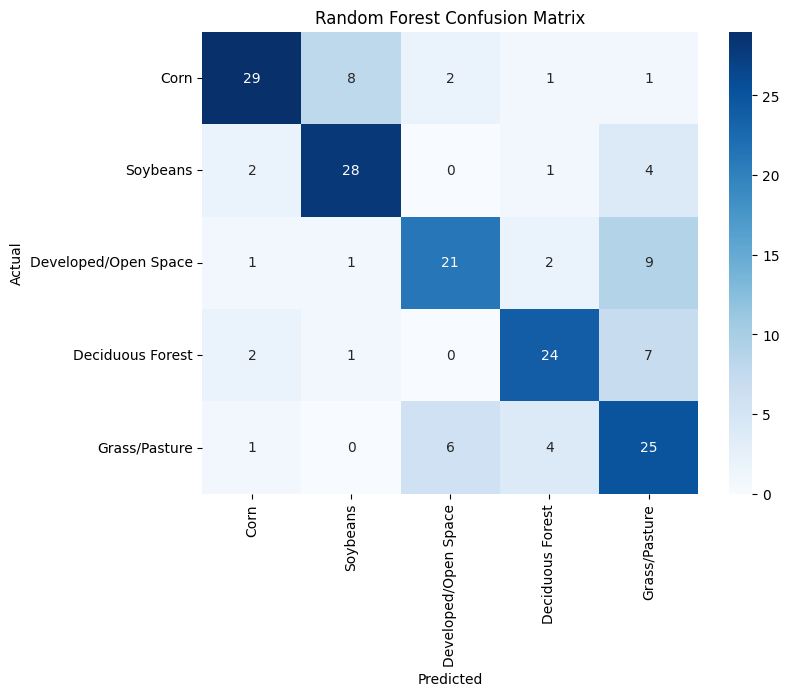

 99%|===================| 892/900 [00:19<00:00]       


SHAP bar plot for Random Forest


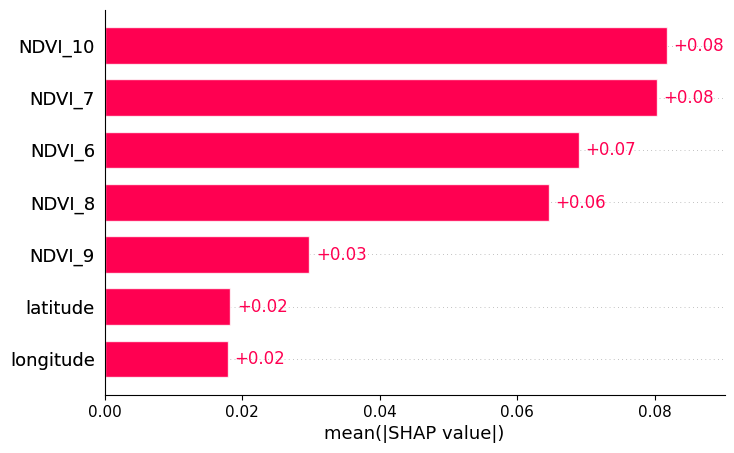


Table 8. Highest performing classifier on reduced NDVI feature set in Iowa


In [33]:
iowa_path = f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{state_name}_{num_points}points_2019_stratified_2019"

# experiment 1: full predictor set
predictor_props_full = [f"NDVI_{m}" for m in range(1, 13)] + ["longitude", "latitude"]

(
    df_iowa_all_full,
    df_iowa_train_full,
    df_iowa_test_full,
    le_iowa_full,
    class_labels_iowa_full,
) = load_dataset(
    iowa_path,
    predictor_props_full,
    label_property,
    top_5_crops,
    analyze=False,
    split=0.9,
)

results_full, cms_full, best_classifier_full = train_classifiers_on_dataset(
    df_iowa_train_full,
    df_iowa_test_full,
    predictor_props_full,
    label_property,
    le_iowa_full,
    class_labels_iowa_full,
    normalize=False,
    grid_search=False,
    verbose=False,
)

print(
    "\n\033[1mTable 7\033[0m. Highest performing classifier on full NDVI feature set in "
    + state_name
)

# experiment 2: reduced predictor set
predictor_props_reduced = [f"NDVI_{m}" for m in range(6, 11)] + [
    "longitude",
    "latitude",
]

(
    df_iowa_all_reduced,
    df_iowa_train_reduced,
    df_iowa_test_reduced,
    le_iowa_reduced,
    class_labels_iowa_reduced,
) = load_dataset(
    iowa_path, predictor_props_reduced, label_property, top_5_crops, analyze=False
)

results_reduced, cms_reduced, best_classifier_reduced = train_classifiers_on_dataset(
    df_iowa_train_reduced,
    df_iowa_test_reduced,
    predictor_props_reduced,
    label_property,
    le_iowa_reduced,
    class_labels_iowa_reduced,
    normalize=False,
    grid_search=False,
    verbose=True,
)

print(
    "\n\033[1mTable 8\033[0m. Highest performing classifier on reduced NDVI feature set in "
    + state_name
)

### 3.3 - Iowa + Illinois

#### 3.3.1 NDVI

We experimented by sampling 200 points per crop for each state (Iowa and Illinois) over several years. When we trained classifiers on these datasets, the performance was roughly the same as when using larger sample sizes. This suggests that 200 points per crop provide sufficient information for robust classification without incurring extra computational overhead.

In [34]:
states = ["IA", "IL"]
years = ["2018", "2019", "2020"]
num_points_per_crop = 200
ndvi_months = [6, 7, 8, 9, 10, 11]

for state_abbr in states:
    region_geom = get_state_geometry([state_abbr])
    for year in years:
        ndvi_collection = get_landsat_ndvi_collection(
            start_date=f"{year}-06-01", end_date=f"{year}-11-30", region=region_geom
        )
        all_samples = ee.FeatureCollection([])

        for crop_code, crop_name in top_5_crops.items():
            cdl_image = (
                ee.Image(f"USDA/NASS/CDL/{year}").select("cropland").clip(region_geom)
            )
            samples = sample_crop_locations(
                cdl_image=cdl_image,
                crop_code=crop_code,
                crop_name=crop_name,
                region_geom=region_geom,
                num_points=num_points_per_crop,
            ).map(lambda f: f.set({"crop_code": crop_code, "crop_name": crop_name}))
            all_samples = all_samples.merge(samples)

        samples_with_ndvi = all_samples.map(
            lambda f: add_selected_monthly_ndvi(f, ndvi_collection, year)
        ).map(add_coordinates)
        samples_with_ndvi = samples_with_ndvi.randomColumn("random", seed=42)

        asset_name = (
            f"{state_abbr}_{num_points_per_crop}pts_{year}_stratified_NDVI6to11"
        )
        export_dataset_as_asset(samples_with_ndvi, region_name=asset_name, year=year)

predictor_props = [f"NDVI_{m}" for m in ndvi_months] + ["longitude", "latitude"]

(
    df_combined_all,
    df_combined_train,
    df_combined_test,
    le_combined,
    class_labels_combined,
) = load_dataset(
    iowa_illinois_ndvi_paths,
    predictor_props,
    label_property,
    top_5_crops,
    analyze=False,
)

results_combined, cms_combined, best_classifier_combined = train_classifiers_on_dataset(
    df_combined_train,
    df_combined_test,
    predictor_props,
    label_property,
    le_combined,
    class_labels_combined,
    normalize=False,
    grid_search=False,
    verbose=False,
)

print(
    "\n\033[1mTable 9\033[0m. Highest performing classifier on combined NDVI feature set for Iowa & Illinois"
)

+---------------+------------+
| Classifier    |   Accuracy |
+===============+============+
| Random Forest |     0.6837 |
+---------------+------------+

Table 9. Highest performing classifier on combined NDVI feature set for Iowa & Illinois


#### 3.3.3 + NDWI, SAVI, EVI

In this part, we explored whether incorporating additional vegetation indicators—NDWI, EVI, and SAVI—into our NDVI time series would improve classifier performance. We applied these indices to our Iowa–Illinois dataset and exported the enhanced features as new assets. Ultimately, we found that adding more vegetation indicators resulted in roughly the same performance as using NDVI alone. However, after some feature reduction, the statistics from the time series performed a bit better.

In [246]:
for asset in iowa_illinois_ndvi_paths:
    fc_ndvi = ee.FeatureCollection(asset)
    year = asset[-4:]  # extract year from asset name

    sample_feature = fc_ndvi.first()
    region_geom = sample_feature.geometry()

    ndwi_collection = get_landsat_ndwi_collection(
        f"{year}-06-01", f"{year}-11-30", region=region_geom
    )
    fc_with_ndwi = fc_ndvi.map(
        lambda f: add_selected_monthly_index(f, ndwi_collection, year, "NDWI")
    )

    evi_collection = get_landsat_evi_collection(
        f"{year}-06-01", f"{year}-11-30", region=region_geom
    )
    fc_with_evi = fc_with_ndwi.map(
        lambda f: add_selected_monthly_index(f, evi_collection, year, "EVI")
    )

    savi_collection = get_landsat_savi_collection(
        f"{year}-06-01", f"{year}-11-30", region=region_geom, L=0.5
    )
    fc_with_all = fc_with_evi.map(
        lambda f: add_selected_monthly_index(f, savi_collection, year, "SAVI")
    )

    other_basename = make_other_basename(asset)

    export_other_asset(fc_with_all, other_basename, year)


#### 3.3.3 + Statistics

+---------------+------------+
| Classifier    |   Accuracy |
+===============+============+
| Random Forest |      0.675 |
+---------------+------------+

Table 10. Highest performing classifier on full NDVI, NDWI, EVI, SAVI feature set for Iowa & Illinois
+---------------+------------+
| Classifier    |   Accuracy |
+===============+============+
| Random Forest |     0.6783 |
+---------------+------------+


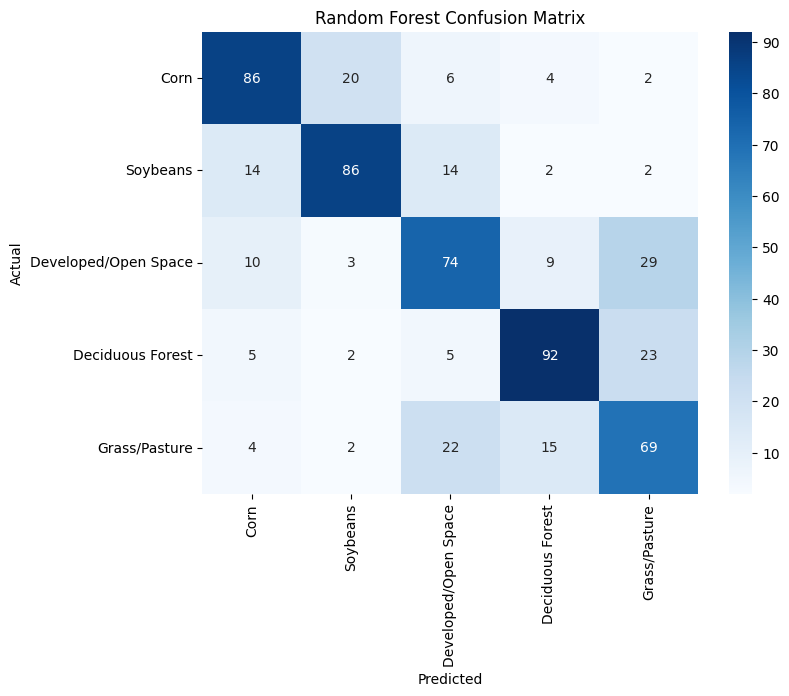

 41%|========            | 1240/3000 [01:21<01:54]       

In [ ]:
# define months, indices, and predictor lists
months = [6, 7, 8, 9, 10, 11]
indices = ["EVI", "NDVI", "NDWI", "SAVI"]

monthly_features = [f"{idx}_{m}" for idx in indices for m in months]
base_predictors = monthly_features + ["longitude", "latitude"]

statistical_metrics_all = [f"{idx}_{metric}" for idx in indices for metric in ["mean", "std", "max", "min"]]
phenological_metrics_all = [f"{idx}_{metric}" for idx in indices for metric in ["peak", "start", "end", "length"]]

full_predictors = base_predictors + statistical_metrics_all + phenological_metrics_all

# load dataset using only base predictors
df_all_other_base, _, _, le_other, class_labels_other = load_dataset(
    iowa_illinois_other_paths,
    base_predictors,
    label_property,
    top_5_crops,
    analyze=False,
    split=0.90,
)

# compute extra metrics for each index
for idx in indices:
    df_all_other_base = compute_index_statistics(df_all_other_base, idx, months)
    df_all_other_base = compute_index_phenology(df_all_other_base, idx, months)

# re-split dataset using the full predictor list
df_other_train = df_all_other_base[df_all_other_base["random"] < 0.90].dropna(subset=full_predictors + [label_property])
df_other_test = df_all_other_base[df_all_other_base["random"] >= 0.90].dropna(subset=full_predictors + [label_property])

# train and evaluate classifiers on full predictor set
results_other, cms_other, best_classifier_other = train_classifiers_on_dataset(
    df_other_train,
    df_other_test,
    full_predictors,
    label_property,
    le_other,
    class_labels_other,
    normalize=True,
    grid_search=False,
    verbose=False,
)

print("\n\033[1mTable 10\033[0m. Highest performing classifier on full NDVI, NDWI, EVI, SAVI feature set for Iowa & Illinois")

# choose a reduced feature set guided by SHAP analysis
predictor_props_other_reduced = [
    "NDVI_10",
    "NDWI_9",
    "NDVI_max",
    "NDVI_peak",
    "NDVI_7",
    "NDVI_8",
    "NDVI_9",
    "NDVI_mean",
    "NDVI_start",
    "latitude",
    "longitude",
    "NDVI_6",
    "NDWI_peak",
    "NDVI_11",
    "EVI_max",
    "EVI_peak",
    "EVI_7",
    "NDWI_max",
    "EVI_mean",
    "EVI_10",
    "SAVI_peak",
    "NDWI_10",
    "SAVI_7",
    "EVI_8",
    "EVI_11",
]

# subset train/test DataFrames to reduced feature set plus label
df_train_other_reduced = df_other_train[predictor_props_other_reduced + [label_property]].copy()
df_test_other_reduced = df_other_test[predictor_props_other_reduced + [label_property]].copy()

# train and evaluate classifier on reduced predictor set
results_other_reduced, cms_other_reduced, best_classifier_other_reduced = train_classifiers_on_dataset(
    df_train_other_reduced,
    df_test_other_reduced,
    predictor_props_other_reduced,
    label_property,
    le_other,
    class_labels_other,
    normalize=True,
    grid_search=False,
    verbose=True,
)

print("\n\033[1mTable 11\033[0m. Highest performing classifier on reduced feature set for Iowa & Illinois")


### Task 3.1: Model Development

Develop a classification model to predict crop type using satellite imagery and temporal vegetation data as input features. The model should be trained on the sampled points from Task 2 and output predictions for the 5 major crops plus a "other" class.

Key Requirements:

- Use sampled crop points (or sampling script) from Task 2 as training data.
- You may want to include more samples for the model than what was created in Task 2.
- Input features must include, but are not limited to, Landsat surface reflectance imagery from the growing season.
- Incorporate temporal vegetation indices like NDVI time series.
- Output predictions for the 5 major crops identified in Task 1 plus an "other" class. This "other" class could be expanded into multiple classes if deemed useful.
- Document modeling methodology including:
  - Model type, input features, training approach
  - Any data preprocessing/augmentation
  - Tools and libraries used
  - Modeling can be fully in GEE or combine external tools like Scikit-learn, Tensorflow, etc.

Remember that ideally, we are attempting to build a model that does NOT require data across the entire year. Put another way, the less data our model needs about the growing season to make a good prediction about the crop type, the better!

If this proves challenging, start by using an entire year's worth of data for your model (like CDL). Achieving good performance with your classifier with a full year's worth of data will earn you full credit, and extra credit will be given to in-season prediction.

### Task 3.2: Model Testing

Validate the performance of the developed crop classification model using accuracy metrics calculated on a held-out test set. This test set can be created with the same sampling strategy from before, but should be created indepdently of the training and validation data (e.g. not be seen by the model at all before testing).

Key Requirements:

- Reserve 10-20% of the training data to hold out for testing.
- Calculate precision, recall and F1 score metrics on the test set.
- Generate a confusion matrix showing per-class accuracies and errors.
- Analyze the results - where does the model perform well or poorly?
- The validation script must enable testing on new unseen data.

Interpret what the results imply about the real-world viability of the model. It's okay if you don't think your model is anywhere nearly as good as CDL is. Identify areas for improvement and potential next steps to further improve performance. Finally, document insights gained from the validation process and analysis of the results.

### Task 3.3: Model Deployment

We're at the end, now it's time to see how our model does over an entire county! Apply the developed crop classification model to full counties to create prediction maps and visually compare against ground truth data.

Key Requirements:

- Script should take any county as an input and produce an output classification.
- Specifically generate output classification results for two counties: (1) Crawford County, Iowa (2) Grant County, Wisconsin. (NOTE we did not train at all in Wisconsin!)
- Run the model over all the pixels of each county.
- Output crop classification maps with predictions at 30 meter resolution.
- Visually compare the model outputs to the Cropland Data Layer (CDL).
- Document any data exports or external processing required.

If your model was built entirely in GEE (recommended), deployment should be straightforward. If your model however was built outside of GEE and you had to export lots of data to run your mode, you may need to ingest results back into GEE (if needed) for visualization and comparison.

Analyze similarities and differences between your model output and the CDL. Do they line up at all? Is your approach viable for real-world deployment? How do the results differ when looked at a much larger geographic scale compared to the test set?

## Tips
- Start small and iterate! Begin by testing workflows on small counties before expanding to the full two states. This will help identify any issues early.
- Leverage the vast data in GEE! The Cropland Data Layer and Landsat imagery on GEE provide a rich dataset. But feel free to incorporate any other relevant data sources available.
- Plan exporting data from GEE! For large regional analysis, you may need to batch export preprocessed data to your local environment for modeling.
- Store off computationally heavy intermediate results! you may want to store intermediate FeatureCollections and Images as GEE assets such that you do not have to dynamically re-create them every time.
- Documentation is key! Thoroughly document your methodology, thought process, experiments, and results. This transparency is important for full credit.
- Visualizations tell a story! Use insightful visuals like time series plots and comparison maps to showcase your findings.
- There are many valid approaches! This assignment is open-ended by design. There are many "correct" ways to analyze the data and build models.
- Ask questions early! Please reach out if you need any guidance or get stuck. I'm happy to provide clarification and nudges in the right direction.